# Final Ödevi - Metin Ön İşleme ve Zipf Yasası Analizi
Bu çalışmada iş ilanlarından oluşan bir veri seti üzerinde metin ön işleme adımları uygulanmış ve Zipf Yasası analiz edilmiştir.

## Veri Seti Bilgileri

- **Kaynak:** Yerel olarak sağlanan "all_job_post.csv" veri seti
- **Elde edilme yöntemi:** Veri seti hazır olarak temin edilmiştir
- **Dosya formatı:** CSV
- **Dosya boyutu:** 4.68 MB
- **Toplam doküman sayısı:** 1167

### Sütunlar:
- job_id: İlan kimlik numarası
- category: İş kategorisi (HR, IT vb.)
- job_title: İlan başlığı
- job_description: İlan açıklaması (analiz bu sütun üzerinden yapılmıştır)
- job_skill_set: Aranan yetenekler

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import re
from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Emren\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Emren\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Emren\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Veri seti yükleniyor ve inceleniyor

In [11]:
import pandas as pd

df = pd.read_csv("C:/Users/Emren/OneDrive/Masaüstü/veriseti/all_job_post.csv")

print("İlk 5 satır:")
display(df.head())

İlk 5 satır:


,job_id,category,job_title,job_description,job_skill_set
0,3902668440,HR,Sr Human Resource Generalist,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,"['employee relations', 'talent acquisition', '..."
1,3905823748,HR,Human Resources Manager,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,"['Talent Acquisition', 'Employee Performance M..."
2,3905854799,HR,Director of Human Resources,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,"['Human Resources Management', 'Recruitment', ..."
3,3905834061,HR,Chief Human Resources Officer,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,"['talent management', 'organizational developm..."
4,3906250451,HR,Human Resources Generalist (Hybrid Role),DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,"['Microsoft Office', 'Data analysis', 'Employe..."


## Zipf Yasası Analizi (Ham Veri)

Bu analizde ham veri üzerinde kelime frekansları incelenmiştir.

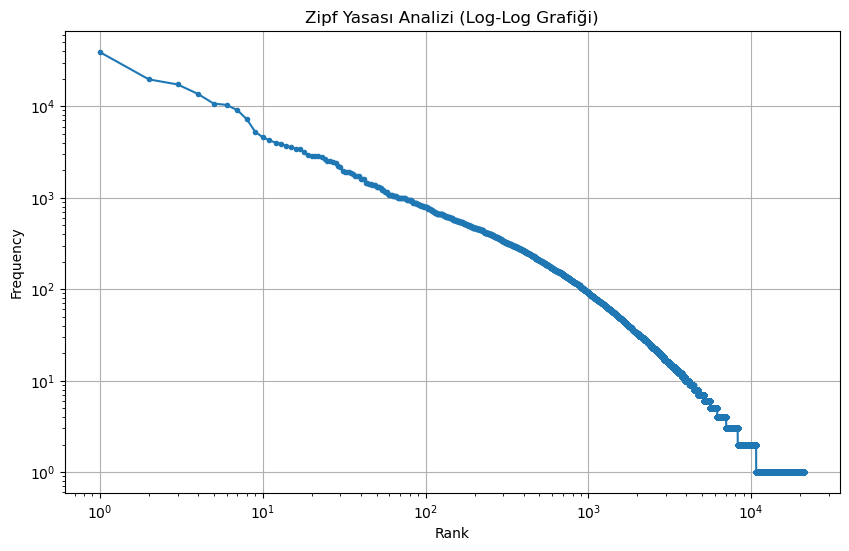

In [5]:
all_text = " ".join(df['job_description'].astype(str)).lower()

words = re.findall(r'\b\w+\b', all_text)
word_counts = Counter(words)

frequencies = sorted(word_counts.values(), reverse=True)
ranks = range(1, len(frequencies) + 1)

plt.figure(figsize=(10,6))
plt.loglog(ranks, frequencies, marker=".")
plt.title("Zipf Yasası Analizi (Log-Log Grafiği)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

## Genel Temizlik (HTML, sayı ve özel karakterlerin kaldırılması)

Bu aşamada metin içerisindeki gereksiz karakterler temizlenmiştir.

In [7]:
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

print("ÖNCE:")
print(df['job_description'][0][:200])

df['clean_text'] = df['job_description'].apply(clean_text)

print("\nSONRA:")
print(df['clean_text'][0][:200])

ÖNCE:
SUMMARY
THE SR. HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING EMPLOYEE RELATIONS, TALENT ACQUISITION, PERFORMANCE MANAGEMENT, PAYROLL, COMPENSATION AND BENEFITS. THE SR. HR GE

SONRA:
SUMMARY
THE SR HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING EMPLOYEE RELATIONS TALENT ACQUISITION PERFORMANCE MANAGEMENT PAYROLL COMPENSATION AND BENEFITS THE SR HR GENERALIS


## Lowercasing (Küçük harfe çevirme)

Metinler tamamen küçük harfe dönüştürülmüştür.

In [9]:
print("ÖNCE:")
print(df['clean_text'][0][:100])

df['lower_text'] = df['clean_text'].str.lower()

print("\nSONRA:")
print(df['lower_text'][0][:100])

ÖNCE:
SUMMARY
THE SR HR GENERALIST PROVIDES HR EXPERTISE ACROSS VARIOUS FUNCTIONS INCLUDING EMPLOYEE RELAT

SONRA:
summary
the sr hr generalist provides hr expertise across various functions including employee relat


## Tokenization (Cümle ve kelime ayrımı)

Metinler hem cümlelere hem de kelimelere ayrılmıştır.

In [11]:
print("ÖNCE:")
print(df['lower_text'][0][:100])

df['sentences'] = df['lower_text'].apply(sent_tokenize)
df['tokens'] = df['lower_text'].apply(word_tokenize)

print("\nSONRA (kelimeler):")
print(df['tokens'][0][:10])

ÖNCE:
summary
the sr hr generalist provides hr expertise across various functions including employee relat

SONRA (kelimeler):
['summary', 'the', 'sr', 'hr', 'generalist', 'provides', 'hr', 'expertise', 'across', 'various']


## Stopword temizleme

Bu aşamada modele katkısı olmayan sık kullanılan kelimeler kaldırılmıştır.

In [13]:
stop_words = set(stopwords.words('english'))

print("ÖNCE:", len(df['tokens'][0]), "kelime")

df['no_stop_words'] = df['tokens'].apply(
    lambda x: [w for w in x if w not in stop_words]
)

print("SONRA:", len(df['no_stop_words'][0]), "kelime")

ÖNCE: 575 kelime
SONRA: 404 kelime


## Lemmatization

Kelimeler sözlük formuna indirgenmiştir.

In [15]:
lemmatizer = WordNetLemmatizer()

print("ÖNCE:")
print(df['no_stop_words'][0][:10])

df['lemmatized'] = df['no_stop_words'].apply(
    lambda x: " ".join([lemmatizer.lemmatize(w) for w in x])
)

print("\nSONRA:")
print(df['lemmatized'][0][:100])

ÖNCE:
['summary', 'sr', 'hr', 'generalist', 'provides', 'hr', 'expertise', 'across', 'various', 'functions']

SONRA:
summary sr hr generalist provides hr expertise across various function including employee relation t


## Stemming

Kelimeler köklerine indirgenmiştir.

In [17]:
stemmer = PorterStemmer()

print("ÖNCE:")
print(df['no_stop_words'][0][:10])

df['stemmed'] = df['no_stop_words'].apply(
    lambda x: " ".join([stemmer.stem(w) for w in x])
)

print("\nSONRA:")
print(df['stemmed'][0][:100])

ÖNCE:
['summary', 'sr', 'hr', 'generalist', 'provides', 'hr', 'expertise', 'across', 'various', 'functions']

SONRA:
summari sr hr generalist provid hr expertis across variou function includ employe relat talent acqui


## Çıktı dosyaları oluşturuluyor

Ödev gereği farklı aşamalardaki veri setleri kaydedilmiştir.

In [19]:
# HAM VERİ
df.to_csv("raw_data.csv", index=False)

# STEMMED
stemmed_df = df[['job_id', 'category', 'job_title', 'stemmed']]
stemmed_df.to_csv("stemmed_data.csv", index=False)

# LEMMATIZED
lemmatized_df = df[['job_id', 'category', 'job_title', 'lemmatized']]
lemmatized_df.to_csv("lemmatized_data.csv", index=False)

print("Tüm dosyalar başarıyla kaydedildi.")

Tüm dosyalar başarıyla kaydedildi.


Amaç: İş ilanlarından oluşan büyük bir veri seti üzerinde Doğal Dil İşleme (NLP) tekniklerini kullanarak veriyi temizlemek ve dillerin istatistiksel yapısını açıklayan Zipf Yasası’nın bu veriler üzerindeki geçerliliğini test etmek.

Yöntem: NLTK ve Pandas kütüphaneleri kullanılarak; metinlerin küçük harfe çevrilmesi, noktalama işaretlerinin ve etkisiz kelimelerin (stop-words) atılması ve kelime köklerine inilmesi (lemmatization) işlemleri gerçekleştirilmiştir.

Bulgular: Yapılan frekans analizleri ve çizilen log-log grafikleri, kelime kullanım sıklıklarının Zipf Yasası ile tam uyumlu olduğunu; yani az sayıda kelimenin çok yüksek frekansla kullanıldığını göstermiştir.

Sonuç: Metin ön işleme adımlarının karmaşık veriyi anlamlı hale getirdiği ve bu temizlenmiş verinin gelecekteki makine öğrenmesi projeleri (sınıflandırma, duygu analizi vb.) için hazır hale getirildiği ortaya konmuştur.